# Г1 Сверточные сети
Выполнил Воскобойников Илья МИВТ-221

# Задание
Задание творческое. 1) Снимите короткое видео (не больше минуты) с некоторым объектом; в течение ролика должен быть промежуток, когда объект закрыт (полностью или частично) 2) Сделайте раскадровку видео 3) Постройте сверточную сеть (используя Keras), которая отделит кадры с объектом от кадров без объекта.


Разметим кадры из снятого видео и уменьшим размерность, а так же создадим чернобелые версии

In [1]:
import shutil
import os
from PIL import Image

DIR_PATH = os.getcwd() + "\\lab1"
DATA_PATH = os.path.join(DIR_PATH, 'IMG-3874')
DATA_MARKUP_PATH = os.path.join(DIR_PATH, 'IMG-3874-markup')
DATA_MARKUP_MONOCHROME_PATH = os.path.join(DIR_PATH, 'IMG-3874-monochrome')
# Все кадры видео
all_data = [
    file
    for file in os.listdir(DATA_PATH)
]
# Не размеченные кадры из видео
not_murk_up_file = [
    file
    for file in all_data
    if '_' not in file
]

print(f'Всего файлов: {len(all_data)}')
print(f'Не размеченных: {len(not_murk_up_file)}')

# 0 - на кадре нет Алисы
# 1 - на кадре присутствует Алиса
# В словаре указаны диапазоны кадров подходящих под условие
RANGES_TO_FLAGS = {
    0: (
        (1, 34),
        (223, 240),
    ),
    1: (
        (35, 222),
    )
}


# получение названия неразмеченного файла по номеру кадра
def get_name(number: int) -> str:
    return f'{str(number).zfill(4)}.jpg'


# Проход по типам кадров
for flag, ranges in RANGES_TO_FLAGS.items():
    flag_counter = 0
    # Проход по диапазонам кадров принадлежащим к типу
    for start, end in ranges:
        # Переименование кадров в название с меткой flag
        for number in range(start, end + 1):
            prev_name, prev_ext = get_name(number).split('.')
            new_name = f"{flag}_{prev_name}.{prev_ext}"
            new_path = os.path.join(
                DATA_MARKUP_PATH,
                new_name
            )
            shutil.copyfile(
                os.path.join(DATA_PATH, f'{prev_name}.{prev_ext}'),
                new_path
            )

            # сжатие изображения
            image = Image.open(new_path)
            image = image.resize((216, 384), Image.BOX)
            image.save(new_path)

            # В чернобелый вид
            image.convert('L').save(
                os.path.join(
                    DATA_MARKUP_MONOCHROME_PATH,
                    new_name
                )
            )

            flag_counter += 1
    print(f"Всего кадров типа {flag}: {flag_counter}")

Всего файлов: 240
Не размеченных: 240


C:\Users\500a5\AppData\Local\Temp\ipykernel_15740\1028430740.py:63: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  image = image.resize((216, 384), Image.BOX)


Всего кадров типа 0: 52
Всего кадров типа 1: 188


Загрузка изображений в память

In [2]:
import numpy as np
import matplotlib.pylab as plt
from random import shuffle

%matplotlib inline

# Функция для получения X и Y датасета
def load_data(path: str) -> (np.array, np.array):
    # Загрузка определенного типа изображений
    def load_images_by_cluster(cluster: int) -> np.array:
        data = [
            plt.imread(
                os.path.join(
                    path,
                    file
                )
            )
            for file in os.listdir(path)
            if int(file.split('_')[0]) == cluster
        ]
        shuffle(data)
        return np.array(data)


    with_hedgehog_images = load_images_by_cluster(1)
    without_hedgehog_images = load_images_by_cluster(0)

    # Добавление метки кластера
    def add_mark(data: np.array, cluster: int) -> [(np.array, int)]:
        return [
            (
                image,
                cluster
            )
            for image in data
        ]


    data = \
        add_mark(with_hedgehog_images, 1) \
        + \
        add_mark(without_hedgehog_images, 0)

    # Перемешиваем выборку
    shuffle(data)


    # Разделение выборки на X и Y
    x, y = list(zip(*data))
    return np.array(x), np.array(y)

Xs, Ys = load_data(DATA_MARKUP_PATH)
Xs_monochrome, Ys_monochrome = load_data(DATA_MARKUP_MONOCHROME_PATH)

Вывод информации об обучающей выборке

In [3]:
print(f'Размерность изображений: {Xs[0].shape}')
print(f'Размерность монохромного изображения: {Xs_monochrome[0].shape}')
print(f'Количество изображений в выборке: {Xs.shape[0]}')

Размерность изображений: (384, 216, 3)
Размерность монохромного изображения: (384, 216)
Количество изображений в выборке: 240


In [4]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


Описание модели сверточной нейронной сети для цветных картинок

In [5]:

from keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Normalization

model = Sequential()
model.add(Normalization())
model.add(
    Conv2D(
        100,
        (5, 5),
        input_shape=Xs[0].shape,
        activation='relu',
        padding='same'
    )
)
model.add(Normalization())
model.add(MaxPooling2D((10, 10), padding='valid'))
model.add(
    Conv2D(
        50,
        (2, 2),
        activation='relu',
        padding='same'
    )
)
model.add(Normalization())
model.add(MaxPooling2D(pool_size=(2, 2), padding='valid'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

Описание модели сверточной нейронной сети для чернобелых картинок

In [6]:
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Conv1D

model_monochrome = Sequential()
model_monochrome.add(Normalization())
model_monochrome.add(
    Conv1D(
        100,
        (5,),
        input_shape=Xs_monochrome[0].shape,
        activation='relu',
        padding='same'
    )
)
model_monochrome.add(Normalization())
model_monochrome.add(MaxPooling1D((10,), padding='valid'))
model_monochrome.add(
    Conv1D(
        50,
        (2,),
        activation='relu',
        padding='same'
    )
)
model_monochrome.add(Normalization())
model_monochrome.add(MaxPooling1D(pool_size=(2,), padding='valid'))
model_monochrome.add(Flatten())
model_monochrome.add(Dense(64, activation='relu'))
model_monochrome.add(Dense(32, activation='relu'))
model_monochrome.add(Dense(1, activation='sigmoid'))

model_monochrome.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

Функция визуализации результатов обучения

In [7]:
from datetime import datetime
from IPython.display import SVG
from keras.utils import model_to_dot

def teach(model, Xs, Ys, postfix):
    start = datetime.now()

    history = model.fit(
       Xs, Ys,
        batch_size=10,
        epochs=10,
        verbose=1,
        validation_split=0.1
    )
    end = datetime.now()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'model accuracy {postfix}')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'model loss {postfix}')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    print(f'Время обучения: {end - start}')
    print(f'Итоговая точность на тренировочной выборке: {history.history["accuracy"][-1]}')
    print(f'Итоговая точность на тестовой выборке: {history.history["val_accuracy"][-1]}')
    print(f'Итоговая ошибка на тренировочной выборке: {history.history["loss"][-1]}')
    print(f'Итоговая ошибка на тестовой выборке: {history.history["val_loss"][-1]}')
    # display(SVG(model_to_dot(model, show_shapes=True).create(prog='dot', format='svg')))

Обучение для цветных изображений

Epoch 1/10
22/22 [==============================] - 9s 366ms/step - loss: 9.8144 - accuracy: 0.7269 - val_loss: 0.1547 - val_accuracy: 0.8750
Epoch 2/10
22/22 [==============================] - 8s 363ms/step - loss: 0.3809 - accuracy: 0.8519 - val_loss: 0.0502 - val_accuracy: 0.9583
Epoch 3/10
22/22 [==============================] - 8s 359ms/step - loss: 0.1559 - accuracy: 0.9491 - val_loss: 0.0158 - val_accuracy: 1.0000
Epoch 4/10
22/22 [==============================] - 8s 361ms/step - loss: 0.0744 - accuracy: 0.9491 - val_loss: 0.0036 - val_accuracy: 1.0000
Epoch 5/10
22/22 [==============================] - 8s 360ms/step - loss: 0.0666 - accuracy: 0.9907 - val_loss: 5.7045e-04 - val_accuracy: 1.0000
Epoch 6/10
22/22 [==============================] - 8s 359ms/step - loss: 0.0401 - accuracy: 0.9861 - val_loss: 2.2588e-04 - val_accuracy: 1.0000
Epoch 7/10
22/22 [==============================] - 8s 359ms/step - loss: 0.0414 - accuracy: 0.9861 - val_loss: 7.4897e-04 - val_accuracy: 1

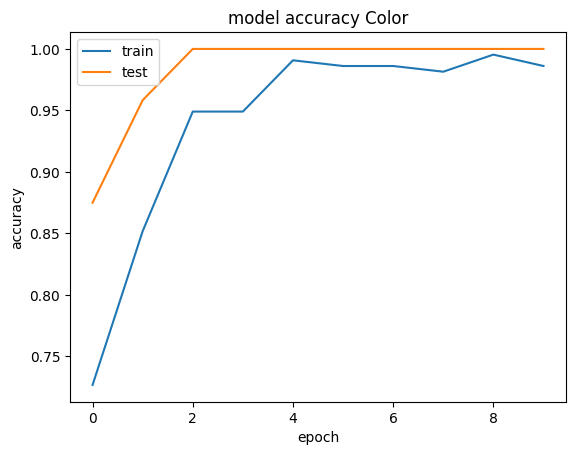

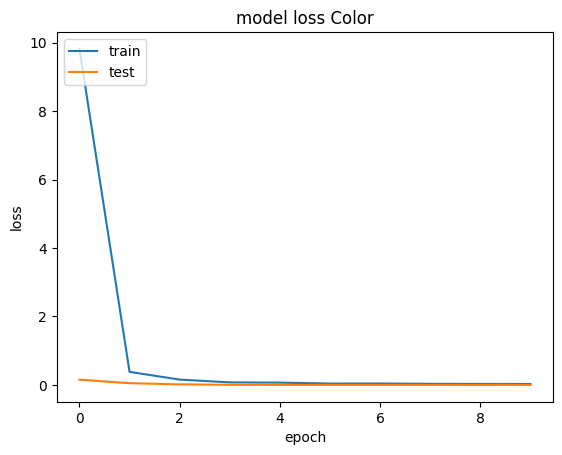

Время обучения: 0:01:20.043799
Итоговая точность на тренировочной выборке: 0.9861111044883728
Итоговая точность на тестовой выборке: 1.0
Итоговая ошибка на тренировочной выборке: 0.027028001844882965
Итоговая ошибка на тестовой выборке: 0.0009882552549242973


In [8]:
teach(model, Xs, Ys, 'Color')

Обучение для чернобелых изображений

Epoch 1/10
22/22 [==============================] - 1s 17ms/step - loss: 13.8495 - accuracy: 0.6620 - val_loss: 29.9498 - val_accuracy: 0.7083
Epoch 2/10
22/22 [==============================] - 0s 13ms/step - loss: 5.2652 - accuracy: 0.7778 - val_loss: 11.2793 - val_accuracy: 0.7083
Epoch 3/10
22/22 [==============================] - 0s 13ms/step - loss: 7.8332 - accuracy: 0.7361 - val_loss: 6.6005e-04 - val_accuracy: 1.0000
Epoch 4/10
22/22 [==============================] - 0s 13ms/step - loss: 0.6695 - accuracy: 0.9398 - val_loss: 3.6100 - val_accuracy: 0.7500
Epoch 5/10
22/22 [==============================] - 0s 13ms/step - loss: 0.8693 - accuracy: 0.9259 - val_loss: 2.0266e-04 - val_accuracy: 1.0000
Epoch 6/10
22/22 [==============================] - 0s 13ms/step - loss: 0.1483 - accuracy: 0.9676 - val_loss: 0.0012 - val_accuracy: 1.0000
Epoch 7/10
22/22 [==============================] - 0s 12ms/step - loss: 0.0824 - accuracy: 0.9815 - val_loss: 9.7315e-09 - val_accuracy: 1.000

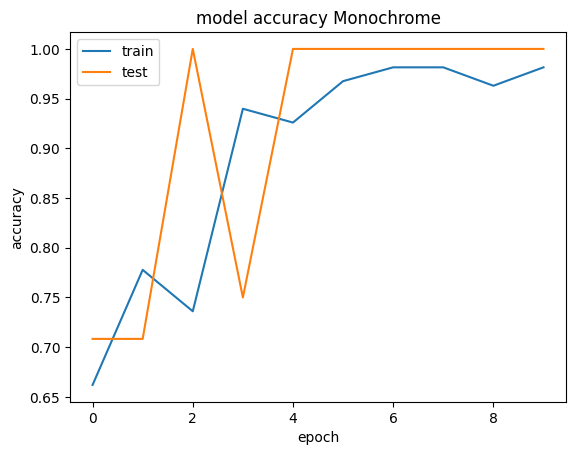

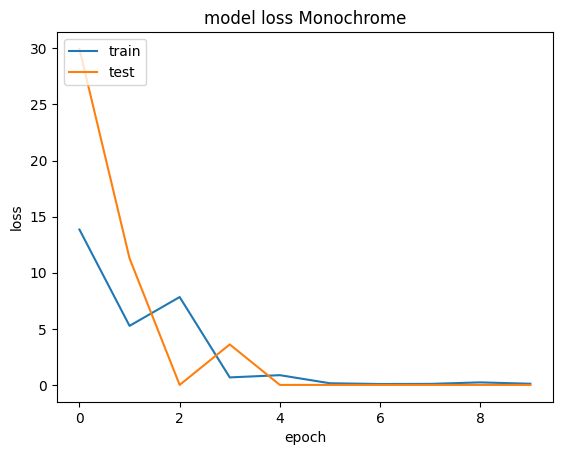

Время обучения: 0:00:03.558669
Итоговая точность на тренировочной выборке: 0.9814814925193787
Итоговая точность на тестовой выборке: 1.0
Итоговая ошибка на тренировочной выборке: 0.103683702647686
Итоговая ошибка на тестовой выборке: 5.493431931569148e-09


In [9]:
teach(model_monochrome, Xs_monochrome, Ys_monochrome, 'Monochrome')

# Вывод
В ходе обучения сверточной сети были получены высокие результаты распознования
для цветных изображений - 99%
для чернобелых -98%

Так же было замечено, что время затрачиваемое на обучение на чернобелых изображений в десятки раз меньше при не большой разнице в качестве распознавания
для цветных изображений - 0:01:20.043799
для чернобелых - 0:00:03.558669

